In [1]:
## IMPORT REQUIRED LIBRARIES
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
dataset_path = "Dataset"

In [4]:
# IMAGE SETTINGS
# All images will be resized to 224x224 pixels because EfficientNetB0 accepts this size
IMG_SIZE = 224

BATCH_SIZE = 16  # how many images the model processes at one time

In [5]:
## LOAD TRAINING DATASET
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,   # Random seed for reproducibility
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 4053 files belonging to 6 classes.
Using 3243 files for training.


In [6]:
# LOAD VALIDATION DATASET
# Validation dataset is used to test the model during training
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 4053 files belonging to 6 classes.
Using 810 files for validation.


In [7]:
# SHOW CLASS NAMES
class_names = train_dataset.class_names

print("Classes:")

print(class_names)

Classes:
['Cardboard', 'Glass', 'Metal', 'Organic', 'Paper', 'Plastic']


In [8]:
# PERFORMANCE OPTIMIZATION
AUTOTUNE = tf.data.AUTOTUNE  # AUTOTUNE improves loading speed automatically


train_dataset = train_dataset.prefetch(   # Prefetch loads next batch while model trains current batch and makes training faster

    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

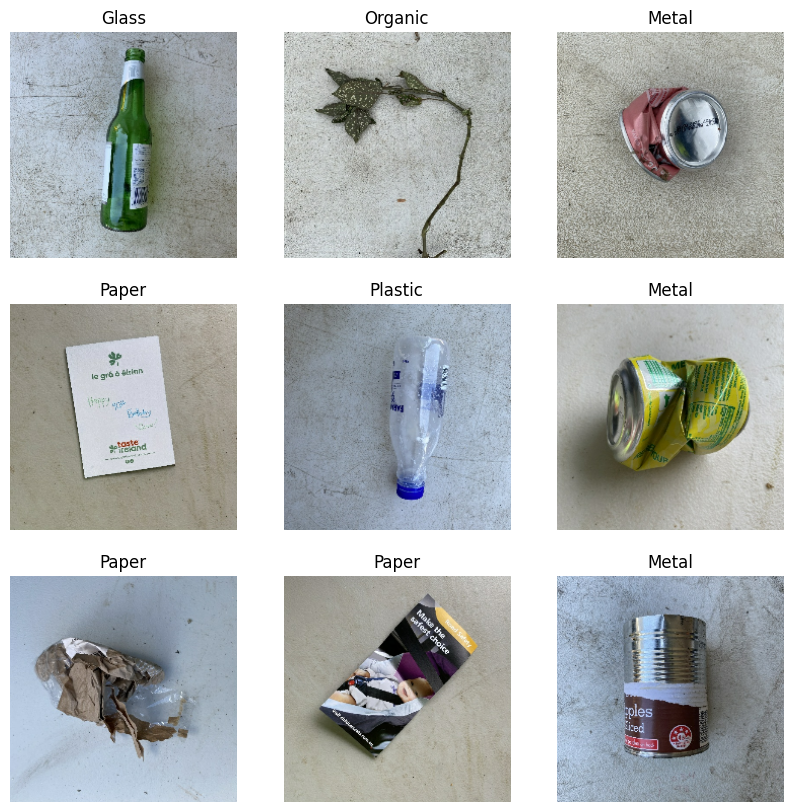

In [9]:
## DISPLAY SAMPLE IMAGES
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(6):  # Display first 9 images

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))   # Convert image tensor into normal image

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [10]:
# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([   # Data augmentation artificially creates variations in images to improve model accuracy.

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

])

In [11]:
# LOAD PRETRAINED EFFICIENTNETB0 MODEL
#EfficientNetB0 is a pretrained CNN model trained on ImageNet dataset

base_model = tf.keras.applications.EfficientNetB0(    # Transfer learning is used here: We reuse learned features instead of training from scratch.

    include_top=False,   # Remove original output layer

    weights='imagenet',     # Use pretrained ImageNet weights

    input_shape=(224,224,3)

)

In [12]:
# FREEZE BASE MODEL
base_model.trainable = False   # Freeze means: pretrained layers will NOT train again

In [13]:
# BUILD FINAL MODEL
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)   # Dropout prevents overfitting Randomly disables some neurons during training

outputs = tf.keras.layers.Dense(

    len(class_names),

    activation='softmax'    # Softmax gives probability for each class

)(x)

model = tf.keras.Model(inputs, outputs)

In [14]:
# COMPILE MODEL
model.compile(

    optimizer=tf.keras.optimizers.Adam(      # Adam optimizer updates weights efficiently
        learning_rate=0.0001
    ),

    loss='sparse_categorical_crossentropy',   # Used for multi-class classification

    metrics=['accuracy']     # Accuracy used to evaluate performance

)

In [15]:
# SHOW MODEL SUMMARY
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# TRAIN MODEL
history = model.fit(    # fit() starts training process

    train_dataset,

    validation_data=validation_dataset,

    epochs=10    # Number of training cycles

)

Epoch 1/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.3799 - loss: 1.5767 - val_accuracy: 0.5222 - val_loss: 1.3359
Epoch 2/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - accuracy: 0.6007 - loss: 1.1787 - val_accuracy: 0.6556 - val_loss: 1.0486
Epoch 3/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - accuracy: 0.6972 - loss: 0.9668 - val_accuracy: 0.7037 - val_loss: 0.8853
Epoch 4/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.7373 - loss: 0.8419 - val_accuracy: 0.7432 - val_loss: 0.7830
Epoch 5/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - accuracy: 0.7635 - loss: 0.7585 - val_accuracy: 0.7667 - val_loss: 0.7128
Epoch 6/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.7872 - loss: 0.6876 - val_accuracy: 0.7827 - val_loss: 0.6614
Epoch 7/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - accuracy: 0.7764 - loss: 0.6596 - val_accuracy: 0.7889 - val_loss: 0.6216
Epoch 8/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - accuracy: 0.8104 - loss: 0

In [18]:
#EVALUATION MODEL
#evaluate() checks model performance

loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss :", loss)

print("Validation Accuracy :", accuracy)

51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.8049 - loss: 0.5444
Validation Loss : 0.5444127917289734
Validation Accuracy : 0.8049382567405701


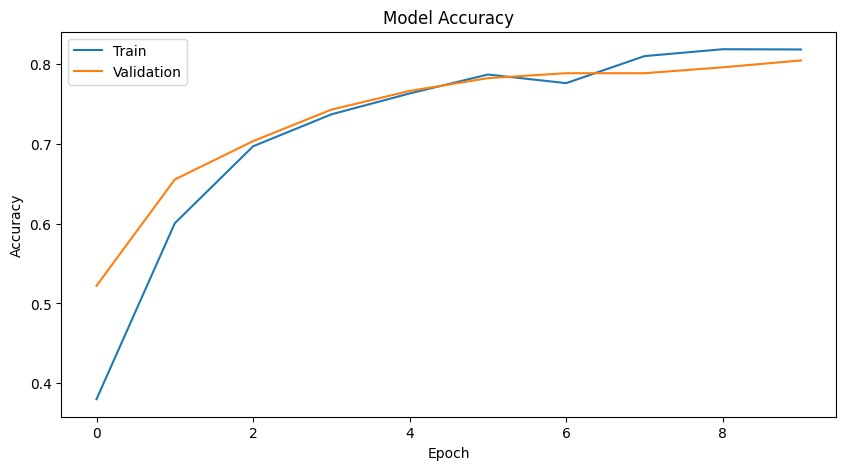

In [19]:
# ACCURACY GRAPH
# Displays training and validation accuracy

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

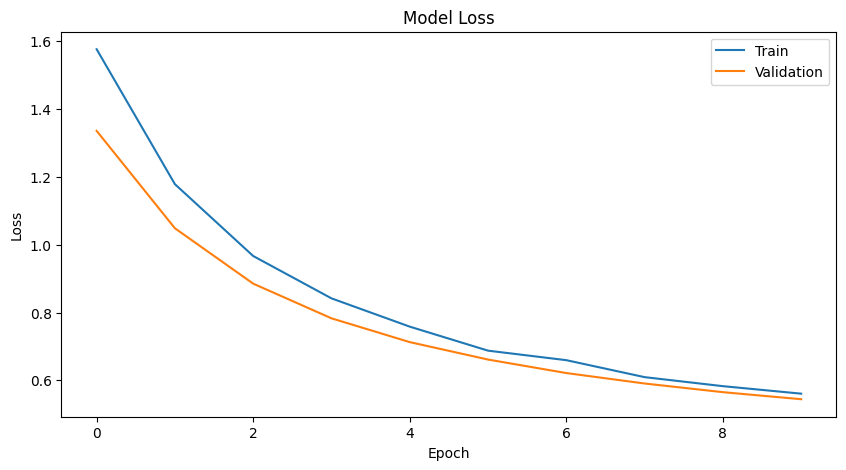

In [20]:
#LOSS GRAPH
# Displays training and validation loss

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [21]:
#SAVE MODEL
model.save("waste_classifier_model.h5")   # Save trained model as .h5 file

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
#TEST SINGLE IMAGE
from tensorflow.keras.preprocessing import image  # Import image preprocessing module

# LOAD TEST IMAGE
img_path = "Dataset/Cardboard/Cardboard_1.jpg"  

img = image.load_img(

    img_path,

    target_size=(224,224)

)

# PREPROCESS IMAGE
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = tf.keras.applications.efficientnet.preprocess_input(
    img_array
)

In [24]:
## PREDICT IMAGE
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print("Predicted Waste Type:")

print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
Predicted Waste Type:
Cardboard
